# Clase 7 -- Sistema Multiagente para Oncologia

## Parte 3: Supervisor + Agentes Especializados

---

### El proyecto completo

| Parte | Agente | Datos | Patron |
|---|---|---|---|
| **Parte 1** | Agente Clinico | Mind map XML de ACME (ensayo clinico CRISPR-Cas9) | Function calling manual |
| **Parte 2** | Agente Farmacologico | Base de datos de medicamentos NSCLC | MCP (Model Context Protocol) |
| **Parte 3** | **Supervisor + ambos agentes** | **Ambas fuentes combinadas** | **LangGraph (create_agent)** |

### De loops manuales a LangGraph

En las Partes 1 y 2, implementamos el agentic loop manualmente:

```
while True:
    response = llm.generate(messages, tools=tools)
    if response tiene function_calls:
        for cada function_call:
            resultado = ejecutar_tool(function_call)
            agregar resultado a messages
    else:
        return response.text  # respuesta final
```

En esta Parte 3 usamos **LangGraph** con `create_agent`, que implementa este loop internamente.
Nosotros solo necesitamos **conectar** las tools con los agentes y los agentes entre si.

```
Usuario -> Supervisor -> Sobre el ensayo clinico? -> Agente Clinico (XML)
                      -> Sobre medicamentos?      -> Agente Farmacologico (DB)
                      -> Cruza ambos dominios?     -> Ambos agentes -> Sintesis
```

## Setup

In [1]:
!pip install -q langchain langchain-google-genai langchain-core langgraph requests

In [2]:
import requests
import xml.etree.ElementTree as ET
import json
import re
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool

import warnings
warnings.filterwarnings('ignore')

print("Setup completo!")

/home/pcokse/Documents/Codigos/Universidad/IApDB/RepositorioPrincipal/facundo-sanchez-ia-biomed/.venv/lib64/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


Setup completo!


In [ ]:
GEMINI_API_KEY = "eliminado"
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=GEMINI_API_KEY)
print(f"Modelo configurado: gemini-2.5-flash")

Modelo configurado: gemini-2.5-flash


---

## Paso 1: Tools y datos del dominio clinico (Parte 1)

Las funciones que acceden al mind map XML de ACME Precision Oncology.

**No modifiques estas celdas.**

In [8]:
# ============================================================
# NO MODIFICAR - Agente Clinico (dado)
# ============================================================

# -- Datos del dominio clinico ----------------------------------------

XML_URL = "https://api.wisemapping.com/api/restful/maps/2030512/document/xml-pub"

def _parse_mindmap(xml_text: str) -> dict:
    root = ET.fromstring(xml_text)
    central = root.find('.//topic[@central="true"]')
    if central is None:
        central = root.find('.//topic')
    def get_text(node):
        t = node.get('text', '')
        if not t:
            te = node.find('text')
            if te is not None and te.text:
                t = te.text.strip()
        return t
    def get_note(node):
        ne = node.find('note')
        return ne.text.strip() if ne is not None and ne.text else ''
    def collect(node, depth=0):
        lines = []
        text = get_text(node)
        note = get_note(node)
        if text:
            indent = "  " * depth
            lines.append(f"{indent}- {text}")
            if note:
                lines.append(f"{indent}  (Nota: {note})")
        for child in node.findall('topic'):
            lines.extend(collect(child, depth + 1))
        return lines
    sections = {}
    central_text = get_text(central)
    for branch in central.findall('topic'):
        name = get_text(branch)
        if name:
            sections[name] = collect(branch)
    return central_text, sections


@tool
def fetch_full_xml() -> str:
    """Descarga y retorna TODOS los datos del mind map de ACME Precision Oncology como texto legible. Usar cuando se necesita una vision completa de la empresa o cuando la pregunta puede involucrar multiples secciones."""
    resp = requests.get(XML_URL)
    resp.raise_for_status()
    title, sections = _parse_mindmap(resp.text)
    output = f"=== {title} ===\n\n"
    for section_name, lines in sections.items():
        output += "\n".join(lines) + "\n\n"
    return output


@tool
def get_section(section_name: str) -> str:
    """Retorna los datos de UNA seccion especifica del mind map de ACME. Mas eficiente que fetch_full_xml cuando se sabe que seccion buscar. Secciones disponibles: Research Especifico, Datos Biomedicos Clave, Modelos Predictivos, Costos del Proyecto, Ensayos Clinicos, Impacto y Mercado, Riesgos, Futuro."""
    resp = requests.get(XML_URL)
    resp.raise_for_status()
    _, sections = _parse_mindmap(resp.text)
    for name, lines in sections.items():
        if section_name.lower() in name.lower():
            return f"Seccion: {name}\n" + "\n".join(lines)
    return f"Seccion '{section_name}' no encontrada. Disponibles: {', '.join(sections.keys())}"


@tool
def list_sections() -> str:
    """Lista todas las secciones principales disponibles en el mind map de ACME. Usar cuando no se sabe que secciones existen."""
    resp = requests.get(XML_URL)
    resp.raise_for_status()
    title, sections = _parse_mindmap(resp.text)
    result = f"Mind map: {title}\n\nSecciones disponibles:\n"
    for i, name in enumerate(sections.keys(), 1):
        result += f"  {i}. {name}\n"
    return result


@tool
def calculate(expression: str) -> str:
    """Evalua una expresion matematica. Usar para calculos como porcentajes, sumas, divisiones. Ejemplo: '420000000 * 0.68' o '85000 * 1200'."""
    cleaned = re.sub(r'[^0-9+\-*/().,%\s]', '', expression)
    cleaned = cleaned.replace('%', '/100').replace(',', '')
    try:
        result = eval(cleaned)
        return f"{expression} = {result}"
    except Exception as e:
        return f"Error: {e}"


# -- Agente Clinico --------------------------------------------------

clinical_tools = [fetch_full_xml, get_section, list_sections, calculate]

clinical_agent = create_agent(
    model,
    tools=clinical_tools,
    system_prompt=(
        "Eres un asistente experto en datos de ACME Precision Oncology. "
        "SIEMPRE usa las tools disponibles para obtener datos antes de responder. "
        "NUNCA inventes datos. Usa datos exactos tal como aparecen en la fuente. "
        "Responde de forma concisa y precisa."
    ),
)

print(f"Agente Clinico creado con {len(clinical_tools)} tools:")
for t in clinical_tools:
    print(f"  - {t.name}")

# Test rapido
result = clinical_agent.invoke({"messages": [("user", "Cuantos pacientes tiene la cohorte?")]})
print(f"\nTest: {result['messages'][-1].content[:200]}")

Agente Clinico creado con 4 tools:
  - fetch_full_xml
  - get_section
  - list_sections
  - calculate

Test: [{'type': 'text', 'text': 'La cohorte tiene un total de 1200 pacientes.', 'extras': {'signature': 'CrsCAQw51senm0KdVDCQgejoEAW5UlZGj8Wbjc/M/0iT2FVKwDJC/DdU+6MCfh2k7KLCqn9lb0WBPi+O204sfSjJhwuRxzD9pBaTKkFyZoZINBNgiW9EdVrEgVBgjVLZHewouvxk4wO/lKXNFPRVuqhC/EOlrO4p9Z389XsiHFFVk/RRzbsXO8CArX1bnblAIx2XOputD/2SZs+CvXBx4r81YvRCYcZ6IkmW2IngRMOm+qaq9vAlvQfwBYg5ZEWvjp/o1XV35UlHDZnOYxZzM1l8dIubFvUrwdMXUG9cn+pwMIqDrbGqL1tBMQGQPsJSk40oR8DjTJ6hm0/tBvmpJoYqt+NPmMHIl3jt6Bo4S75NF98QaPcDNy180Itzzul6qWfBmXzeW9FQPRWfZoYcwPQBJLMifUVlSa4WJvBU'}}]


---

## Paso 2: Datos del dominio farmacologico (Parte 2)

La base de datos de medicamentos para NSCLC.

**No modifiques estas celdas.**

In [9]:
# ============================================================
# NO MODIFICAR - Base de datos farmacologica (dada)
# ============================================================

PHARMA_DB = [
    {
        "name": "Osimertinib",
        "brand": "Tagrisso",
        "drug_class": "EGFR-TKI (3ra generacion)",
        "mechanism": "Inhibidor irreversible de EGFR mutado (L858R, del19, T790M). Se une covalentemente al residuo C797 del dominio kinasa.",
        "targets": ["EGFR-L858R", "EGFR-del19", "EGFR-T790M"],
        "indications": "NSCLC metastasico EGFR+ (1ra linea); NSCLC con T790M post-progresion a TKI previo (2da linea); adyuvante post-cirugia en NSCLC EGFR+ estadios IB-IIIA.",
        "dosage": "80 mg oral/dia (reducir a 40 mg si toxicidad grado 3+)",
        "contraindications": ["Hipersensibilidad al osimertinib", "Embarazo/lactancia", "Enfermedad pulmonar intersticial activa"],
        "side_effects": ["Diarrea (42%)", "Rash (34%)", "Piel seca (23%)", "Paroniquia (22%)", "Estomatitis (15%)", "Prolongacion QTc (3-5%)"],
        "cost_monthly_usd": 14000,
        "evidence": "Nivel 1A — estudios FLAURA (1ra linea), ADAURA (adyuvante), AURA3 (T790M)",
        "approval_year": 2017
    },
    {
        "name": "Erlotinib",
        "brand": "Tarceva",
        "drug_class": "EGFR-TKI (1ra generacion)",
        "mechanism": "Inhibidor reversible competitivo del dominio tirosina-kinasa de EGFR. Bloquea la señalizacion de proliferacion celular.",
        "targets": ["EGFR-L858R", "EGFR-del19"],
        "indications": "NSCLC metastasico EGFR+ (ya no es 1ra linea preferida). Combinacion con ramucirumab o bevacizumab.",
        "dosage": "150 mg oral/dia en ayunas (1h antes o 2h despues de comida)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Insuficiencia hepatica severa"],
        "side_effects": ["Rash acneiforme (75%)", "Diarrea (54%)", "Anorexia (30%)", "Fatiga (25%)", "Nauseas (20%)", "Hepatotoxicidad (2-5%)"],
        "cost_monthly_usd": 7500,
        "evidence": "Nivel 1A — estudio EURTAC, ENSURE",
        "approval_year": 2004
    },
    {
        "name": "Gefitinib",
        "brand": "Iressa",
        "drug_class": "EGFR-TKI (1ra generacion)",
        "mechanism": "Inhibidor reversible selectivo del dominio tirosina-kinasa de EGFR. Similar a erlotinib pero con perfil de selectividad ligeramente diferente.",
        "targets": ["EGFR-L858R", "EGFR-del19"],
        "indications": "NSCLC metastasico EGFR+ (alternativa a erlotinib en 1ra generacion).",
        "dosage": "250 mg oral/dia (con o sin alimentos)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Enfermedad pulmonar intersticial"],
        "side_effects": ["Diarrea (47%)", "Rash (44%)", "Piel seca (28%)", "Nauseas (18%)", "Elevacion transaminasas (10%)", "Enfermedad pulmonar intersticial (1-2%)"],
        "cost_monthly_usd": 6800,
        "evidence": "Nivel 1A — estudio IPASS, NEJ002",
        "approval_year": 2003
    },
    {
        "name": "Afatinib",
        "brand": "Gilotrif",
        "drug_class": "EGFR-TKI (2da generacion)",
        "mechanism": "Inhibidor irreversible pan-HER (EGFR/HER1, HER2, HER4). Bloquea toda la familia ErbB, no solo EGFR.",
        "targets": ["EGFR-L858R", "EGFR-del19", "HER2"],
        "indications": "NSCLC metastasico EGFR+ (alternativa, especialmente en del19). Tambien aprobado para carcinoma escamoso de pulmon post-platino.",
        "dosage": "40 mg oral/dia en ayunas (reducir a 30 mg o 20 mg si toxicidad)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Deterioro renal severo (ClCr <15 ml/min)"],
        "side_effects": ["Diarrea (96%)", "Rash (89%)", "Estomatitis (72%)", "Paroniquia (58%)", "Piel seca (31%)", "Disminucion del apetito (29%)"],
        "cost_monthly_usd": 8200,
        "evidence": "Nivel 1A — estudios LUX-Lung 3, LUX-Lung 6, LUX-Lung 7",
        "approval_year": 2013
    },
    {
        "name": "Pembrolizumab",
        "brand": "Keytruda",
        "drug_class": "Inmunoterapia anti-PD-1",
        "mechanism": "Anticuerpo monoclonal humanizado anti-PD-1. Bloquea el receptor PD-1 en linfocitos T, restaurando la respuesta inmune antitumoral.",
        "targets": ["PD-1"],
        "indications": "NSCLC metastasico PD-L1+ (>=1%) sin mutaciones driver (EGFR/ALK). Monoterapia si PD-L1>=50%; combinacion con quimio si PD-L1 1-49%.",
        "dosage": "200 mg IV cada 3 semanas (o 400 mg IV cada 6 semanas)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Enfermedad autoinmune activa severa", "Uso de inmunosupresores cronicos"],
        "side_effects": ["Fatiga (25%)", "Prurito (18%)", "Rash (15%)", "Diarrea (12%)", "Neumonitis inmunomediada (3-5%)", "Hepatitis inmunomediada (1-3%)", "Tiroiditis (8%)"],
        "cost_monthly_usd": 18000,
        "evidence": "Nivel 1A — estudios KEYNOTE-024 (monoterapia), KEYNOTE-189 (combo con quimio)",
        "approval_year": 2016
    },
    {
        "name": "Docetaxel",
        "brand": "Taxotere",
        "drug_class": "Quimioterapia (taxano)",
        "mechanism": "Estabiliza microtubulos impidiendo su despolimerizacion. Bloquea la mitosis celular en fase M del ciclo celular.",
        "targets": ["Microtubulos"],
        "indications": "NSCLC metastasico como 2da linea post-platino. Tambien en combinacion con cisplatino como 1ra linea.",
        "dosage": "75 mg/m2 IV cada 3 semanas (premedicacion con dexametasona obligatoria)",
        "contraindications": ["Neutrofilos <1500/mm3", "Hipersensibilidad a polisorbato 80", "Embarazo/lactancia", "Insuficiencia hepatica severa"],
        "side_effects": ["Neutropenia (75%)", "Alopecia (65%)", "Fatiga (53%)", "Nauseas (34%)", "Diarrea (25%)", "Neuropatia periferica (20%)", "Retencion de liquidos (15%)"],
        "cost_monthly_usd": 3500,
        "evidence": "Nivel 1A — estudio TAX 317, TAX 320",
        "approval_year": 1999
    },
    {
        "name": "Carboplatin",
        "brand": "Paraplatin",
        "drug_class": "Quimioterapia (platino)",
        "mechanism": "Forma aductos con el ADN generando enlaces cruzados inter e intracatenarios. Inhibe replicacion y transcripcion del ADN tumoral.",
        "targets": ["ADN"],
        "indications": "NSCLC metastasico en combinacion (carbo + pemetrexed, carbo + paclitaxel). Base de muchos esquemas de 1ra linea sin mutacion driver.",
        "dosage": "AUC 5-6 IV cada 3 semanas (calcular dosis por formula de Calvert)",
        "contraindications": ["Hipersensibilidad a compuestos de platino", "Mielosupresion severa", "Embarazo/lactancia", "Insuficiencia renal severa (ClCr <15 ml/min)"],
        "side_effects": ["Trombocitopenia (62%)", "Neutropenia (55%)", "Anemia (48%)", "Nauseas/vomitos (45%)", "Fatiga (35%)", "Nefrotoxicidad (10%)", "Ototoxicidad (5%)"],
        "cost_monthly_usd": 800,
        "evidence": "Nivel 1A — multiples estudios fase III como base de combinaciones",
        "approval_year": 1989
    },
    {
        "name": "Pemetrexed",
        "brand": "Alimta",
        "drug_class": "Quimioterapia (antifolato)",
        "mechanism": "Antifolato multitarget que inhibe timidilato sintasa (TS), dihidrofolato reductasa (DHFR) y glicinamida ribonucleotido formiltransferasa (GARFT).",
        "targets": ["TS", "DHFR", "GARFT"],
        "indications": "NSCLC no escamoso metastasico en combinacion con platino (1ra linea) y como mantenimiento. NO indicado en histologia escamosa.",
        "dosage": "500 mg/m2 IV cada 3 semanas (suplementar con acido folico y vitamina B12 obligatorio)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "ClCr <45 ml/min", "Histologia escamosa de NSCLC"],
        "side_effects": ["Neutropenia (40%)", "Fatiga (35%)", "Nauseas (30%)", "Anemia (20%)", "Estomatitis (15%)", "Rash (10%)", "Elevacion de creatinina (8%)"],
        "cost_monthly_usd": 6000,
        "evidence": "Nivel 1A — estudio PARAMOUNT (mantenimiento), JMDB (1ra linea con cisplatino)",
        "approval_year": 2004
    },
    {
        "name": "Bevacizumab",
        "brand": "Avastin",
        "drug_class": "Antiangiogenico (anti-VEGF)",
        "mechanism": "Anticuerpo monoclonal anti-VEGF-A. Inhibe la angiogenesis tumoral impidiendo la union de VEGF a sus receptores.",
        "targets": ["VEGF-A"],
        "indications": "NSCLC no escamoso metastasico en combinacion con quimioterapia (carbo + paclitaxel + bev). NO usar en histologia escamosa (riesgo hemoptisis).",
        "dosage": "15 mg/kg IV cada 3 semanas (o 7.5 mg/kg cada 3 semanas en algunos esquemas)",
        "contraindications": ["Histologia escamosa", "Hemoptisis reciente", "Cirugia mayor reciente (<28 dias)", "Hipertension no controlada", "Embarazo/lactancia"],
        "side_effects": ["Hipertension (25%)", "Proteinuria (20%)", "Epistaxis (15%)", "Fatiga (12%)", "Hemorragia (8%)", "Perforacion GI (1-2%)", "Tromboembolismo arterial (3%)"],
        "cost_monthly_usd": 9500,
        "evidence": "Nivel 1A — estudio ECOG 4599, AVAiL",
        "approval_year": 2006
    },
    {
        "name": "Crizotinib",
        "brand": "Xalkori",
        "drug_class": "Inhibidor ALK/ROS1",
        "mechanism": "Inhibidor de tirosina kinasa de ALK, ROS1 y MET. Bloquea la señalizacion oncogenica en tumores con reordenamientos ALK o ROS1.",
        "targets": ["ALK", "ROS1", "MET"],
        "indications": "NSCLC metastasico ALK+ (ya no es 1ra linea preferida, reemplazado por alectinib). NSCLC ROS1+.",
        "dosage": "250 mg oral cada 12 horas (con o sin alimentos)",
        "contraindications": ["Hipersensibilidad", "Embarazo/lactancia", "Prolongacion QTc congenita", "Insuficiencia hepatica severa"],
        "side_effects": ["Trastornos visuales (62%)", "Nauseas (55%)", "Diarrea (43%)", "Vomitos (40%)", "Edema (30%)", "Elevacion transaminasas (15%)", "Bradicardia (5%)"],
        "cost_monthly_usd": 16000,
        "evidence": "Nivel 1A — estudio PROFILE 1014 (ALK), PROFILE 1001 (ROS1)",
        "approval_year": 2011
    }
]

INTERACTIONS_DB = [
    {"drug_a": "Osimertinib", "drug_b": "Erlotinib", "severity": "CONTRAINDICADO", "detail": "Mismo target EGFR — toxicidad aditiva sin beneficio clinico. No combinar TKIs del mismo target."},
    {"drug_a": "Osimertinib", "drug_b": "Gefitinib", "severity": "CONTRAINDICADO", "detail": "Mismo target EGFR — toxicidad aditiva sin beneficio clinico."},
    {"drug_a": "Osimertinib", "drug_b": "Afatinib", "severity": "CONTRAINDICADO", "detail": "Ambos inhiben EGFR — riesgo de toxicidad severa (rash, diarrea, prolongacion QTc)."},
    {"drug_a": "Erlotinib", "drug_b": "Gefitinib", "severity": "CONTRAINDICADO", "detail": "Ambos son EGFR-TKI 1ra generacion — mecanismo identico, sin beneficio en combinacion."},
    {"drug_a": "Osimertinib", "drug_b": "Warfarina", "severity": "PRECAUCION", "detail": "Osimertinib es sustrato e inhibidor de CYP3A4. Monitorear INR frecuentemente — riesgo de sangrado aumentado."},
    {"drug_a": "Erlotinib", "drug_b": "Warfarina", "severity": "PRECAUCION", "detail": "Erlotinib inhibe CYP1A2 y CYP3A4. Monitorear INR — reportes de sangrado con uso concomitante."},
    {"drug_a": "Pembrolizumab", "drug_b": "Corticoides", "severity": "PRECAUCION", "detail": "Dosis altas de corticoides (>10 mg prednisona/dia) pueden reducir eficacia de inmunoterapia al suprimir linfocitos T."},
    {"drug_a": "Pembrolizumab", "drug_b": "Osimertinib", "severity": "PRECAUCION", "detail": "Combinacion asociada a mayor incidencia de neumonitis inmunomediada. No recomendada de rutina."},
    {"drug_a": "Carboplatin", "drug_b": "Pemetrexed", "severity": "COMPATIBLE", "detail": "Combinacion estandar de 1ra linea para NSCLC no escamoso. Esquema validado en multiples estudios fase III."},
    {"drug_a": "Carboplatin", "drug_b": "Docetaxel", "severity": "COMPATIBLE", "detail": "Combinacion usada en 1ra linea. Monitorear mielosupresion aditiva (neutropenia)."},
    {"drug_a": "Carboplatin", "drug_b": "Bevacizumab", "severity": "COMPATIBLE", "detail": "Combinacion estandar (carbo + paclitaxel + bev). Solo en histologia no escamosa."},
    {"drug_a": "Carboplatin", "drug_b": "Pembrolizumab", "severity": "COMPATIBLE", "detail": "Combinacion aprobada: carbo + pemetrexed + pembrolizumab (KEYNOTE-189). Esquema estandar para NSCLC no escamoso sin driver."},
    {"drug_a": "Docetaxel", "drug_b": "Bevacizumab", "severity": "PRECAUCION", "detail": "Combinacion posible pero monitorear neutropenia severa y riesgo de sangrado."},
    {"drug_a": "Pemetrexed", "drug_b": "AINEs", "severity": "PRECAUCION", "detail": "AINEs reducen eliminacion renal de pemetrexed. Suspender AINEs 2-5 dias antes de cada ciclo."},
    {"drug_a": "Bevacizumab", "drug_b": "Anticoagulantes", "severity": "PRECAUCION", "detail": "Riesgo aumentado de hemorragia. Monitorear signos de sangrado y ajustar dosis de anticoagulante."},
    {"drug_a": "Crizotinib", "drug_b": "Osimertinib", "severity": "PRECAUCION", "detail": "Ambos prolongan QTc. Si se combinan, monitorear ECG. Targets diferentes (ALK vs EGFR) pero toxicidad cardiaca aditiva."},
    {"drug_a": "Gefitinib", "drug_b": "Omeprazol", "severity": "PRECAUCION", "detail": "IBP reducen absorcion de gefitinib (requiere pH acido). Evitar IBP o usar anti-H2 con separacion de 12h."},
    {"drug_a": "Afatinib", "drug_b": "P-gp inductores", "severity": "PRECAUCION", "detail": "Rifampicina y otros inductores de P-gp reducen niveles de afatinib. Ajustar dosis si uso concomitante necesario."}
]

print(f"Base de datos cargada: {len(PHARMA_DB)} medicamentos, {len(INTERACTIONS_DB)} interacciones")

Base de datos cargada: 10 medicamentos, 18 interacciones


---

## Ejercicio 1: Conectar las tools farmacologicas con LangGraph

Las funciones que acceden a la base de datos ya estan implementadas arriba.
Ahora necesitas **conectarlas como tools de LangGraph** usando el decorador `@tool`.

El decorador `@tool` convierte una funcion Python en una tool que el agente puede usar.
El LLM lee el **docstring** de la funcion para decidir cuando usarla -- funciona como
la "descripcion" que escribiste en las Partes 1 y 2.

```python
@tool
def mi_tool(parametro: str) -> str:
    """Esta descripcion es lo que lee el LLM para decidir cuando usar esta tool."""
    return resultado
```

**Tu tarea:**
1. Decorar las 4 funciones con `@tool`
2. Escribir un **docstring** descriptivo para cada una (que hace, cuando usarla, que retorna)
3. Las funciones internamente ya tienen la logica implementada

In [11]:
# -- TODO: Conectar las tools farmacologicas con @tool ----------

@tool
def search_drug(drug_name: str) -> str:
    # TODO: Escribir docstring descriptivo

    """Busca en la base de datos una droga que es la especificada en el parametro de la función.
    Retorna la información completa de la droga en caso que la encuentre.
    Utilizar esta función cuando se tenga el nombre de la droga que este en la base de datos y se requiera información sobre ella"""
    name_lower = drug_name.lower().strip()
    for drug in PHARMA_DB:
        if name_lower in drug["name"].lower() or name_lower in drug["brand"].lower():
            return json.dumps(drug, indent=2, ensure_ascii=False)
    return f"Medicamento '{drug_name}' no encontrado."


@tool
def check_interaction(drug_a: str, drug_b: str) -> str:
    # TODO: Escribir docstring descriptivo
    """Busca en la base de datos la interacción entre las 2 drogas otorgadas en los 2 parametros de la funcion.
    Retorna la severidad y el detalle de dicha interección en caso que la encuentre.
    Utilizar esta función cuando se tenga el nombre de las 2 drogas que se quiera evaluar su interacción"""
    a_lower = drug_a.lower().strip()
    b_lower = drug_b.lower().strip()
    for ix in INTERACTIONS_DB:
        ia, ib = ix["drug_a"].lower(), ix["drug_b"].lower()
        if (a_lower in ia or a_lower in ib) and (b_lower in ia or b_lower in ib):
            return json.dumps(ix, indent=2, ensure_ascii=False)
    return f"No se encontro interaccion entre '{drug_a}' y '{drug_b}'."


@tool
def list_drugs_by_class(drug_class: str) -> str:
    # TODO: Escribir docstring descriptivo
    """Busca en la base de datos una clase de drogas especificada en el parametro de la función.
    Retorna todas las drogas de esa clase, aporta el nombre, marca, clase y costo mensual de las drogas en caso que las encuentre.
    Utilizar esta función cuando se tenga la clase de drogas y se quiera saber que drogas pertenecen a esa clase y parte de información respecto a las mismas en caso que la encuentre."""
    class_lower = drug_class.lower().strip()
    matches = [
        {"name": d["name"], "brand": d["brand"], "drug_class": d["drug_class"], "cost_monthly_usd": d["cost_monthly_usd"]}
        for d in PHARMA_DB if class_lower in d["drug_class"].lower()
    ]
    if matches:
        return json.dumps(matches, indent=2, ensure_ascii=False)
    classes = sorted(set(d["drug_class"] for d in PHARMA_DB))
    return f"Clase '{drug_class}' no encontrada. Disponibles: {', '.join(classes)}"


@tool
def get_treatment_options(target: str) -> str:
    # TODO: Escribir docstring descriptivo
    """Busca en la base de datos drogas que tengas el target especificado en el parametro de la función.
    Retorna todas las drogas que tengan este target, aporta el nombre, marca, clase, indicaciones y evidencia de las drogas en caso que las encuentre.
    Utilizar esta función cuando se tenga un target y se necesite saber que drogas poseen este target."""
    target_upper = target.upper().strip()
    matches = [
        {"name": d["name"], "brand": d["brand"], "drug_class": d["drug_class"], "indications": d["indications"], "evidence": d["evidence"]}
        for d in PHARMA_DB if any(target_upper in t.upper() for t in d["targets"])
    ]
    if matches:
        return json.dumps(matches, indent=2, ensure_ascii=False)
    all_targets = sorted(set(t for d in PHARMA_DB for t in d["targets"]))
    return f"Target '{target}' no encontrado. Disponibles: {', '.join(all_targets)}"


pharma_tools = [search_drug, check_interaction, list_drugs_by_class, get_treatment_options]

# Verificar
for t in pharma_tools:
    desc = t.description or "(SIN DESCRIPCION)"
    print(f"  {'OK' if t.description else 'FALTA'}: {t.name} -- {desc[:60]}")

  OK: search_drug -- Busca en la base de datos una droga que es la especificada e
  OK: check_interaction -- Busca en la base de datos la interacción entre las 2 drogas 
  OK: list_drugs_by_class -- Busca en la base de datos una clase de drogas especificada e
  OK: get_treatment_options -- Busca en la base de datos drogas que tengas el target especi


---

## Ejercicio 2: Crear el agente farmacologico con LangGraph

Usa `create_agent` para crear el agente farmacologico.
Necesitas pasarle:
- El **modelo** (ya creado como `model`)
- Las **tools** (la lista `pharma_tools` del ejercicio anterior)
- Un **system_prompt** que le diga al agente que es, que debe hacer y que NO debe hacer

In [12]:
# -- TODO: Crear el agente farmacologico --------------------------

pharma_agent = create_agent(
    model,
    tools=pharma_tools,
    system_prompt="""
Eres un farmaceutico experto en medicamentos que ataquen al cancer de pulmon. Sabes varios medicamentos y todos los datos referentes a ellos.
Las reglas que debes de cumplir son:
1. Siempre responde utilizando las tools descriptas. Nunca inventar las respuestas
2. Tienes que dar una respuesta concisa y con los datos exactos preguntados. Usa un tono profesional y directo
3. Siempre utiliza los datos provistos para responder. Si encontras las respuestas aplica las tools
""",
)

# Test
result = pharma_agent.invoke({"messages": [("user", "Cual es la dosis de osimertinib?")]})
print(f"Test: {result['messages'][-1].content[:200]}")

Test: La dosis de osimertinib es de 80 mg oral/día (reducir a 40 mg si toxicidad grado 3+).


---

## Ejercicio 3: Crear las tools de routing del supervisor

El supervisor necesita 3 tools que **derivan preguntas a los sub-agentes**.
Cada tool es una funcion Python decorada con `@tool` que internamente
llama a un sub-agente con `agent.invoke()`.

**Tu tarea:**
1. Implementar `ask_clinical_agent` -- llama a `clinical_agent.invoke()`
2. Implementar `ask_pharma_agent` -- llama a `pharma_agent.invoke()`
3. Implementar `ask_both_agents` -- llama a AMBOS y combina las respuestas
4. Escribir docstrings descriptivos para cada una

**Pista:** Para invocar un agente y obtener la respuesta:
```python
result = agent.invoke({"messages": [("user", question)]})
respuesta = result["messages"][-1].content
```

In [14]:
# -- TODO: Implementar las tools de routing -----------------------

routing_log = []  # registro de routing (no modificar)

@tool
def ask_clinical_agent(question: str) -> str:
    # TODO: Escribir docstring que explique cuando usar esta tool
    """Útil cuando el usuario pregunta EXCLUSIVAMENTE sobre información del ensayo clínico ACME Precision Oncology"""
    routing_log.append({"tool": "ask_clinical_agent", "question": question})
    # TODO: Invocar clinical_agent y retornar la respuesta
    result = clinical_agent.invoke({"messages": [("user", question)]})
    return result["messages"][-1].content


@tool
def ask_pharma_agent(question: str) -> str:
    # TODO: Escribir docstring que explique cuando usar esta tool
    """Útil cuando el usuario pregunta EXCLUSIVAMENTE sobre medicamentos, dosis, efectos secundarios e interacciones farmacológicas, targets (EGFR, ALK, etc.) o clases de drogas."""
    routing_log.append({"tool": "ask_pharma_agent", "question": question})
    # TODO: Invocar pharma_agent y retornar la respuesta
    result = pharma_agent.invoke({"messages": [("user", question)]})
    return result["messages"][-1].content


@tool
def ask_both_agents(question: str) -> str:
    # TODO: Escribir docstring que explique cuando usar esta tool
    """Útil cuando la pregunta del usuario requiere combinar o cruzar ambos dominios de información (preguntas que mezclan el ensayo clínico y detalles farmacológicos)."""
    routing_log.append({"tool": "ask_both_agents", "question": question})
    # TODO: Invocar AMBOS agentes y combinar las respuestas
    # Formato esperado:
    # "=== Respuesta del Agente Clinico ===\n{resp_clinico}\n\n"
    # "=== Respuesta del Agente Farmacologico ===\n{resp_pharma}"
    res_clinico = clinical_agent.invoke({"messages": [("user", question)]})
    res_pharma = pharma_agent.invoke({"messages": [("user", question)]})

    texto_clinico = res_clinico["messages"][-1].content
    texto_pharma = res_pharma["messages"][-1].content
    
    return f"=== Respuesta del Agente Clinico ===\n{texto_clinico}\n\n=== Respuesta del Agente Farmacologico ===\n{texto_pharma}"
    


supervisor_tools = [ask_clinical_agent, ask_pharma_agent, ask_both_agents]
print(f"Tools de routing: {[t.name for t in supervisor_tools]}")

Tools de routing: ['ask_clinical_agent', 'ask_pharma_agent', 'ask_both_agents']


---

## Ejercicio 4: Crear el supervisor con LangGraph

Usa `create_agent` para crear el supervisor.
El system prompt debe explicarle:
- Que agentes tiene disponibles y que sabe cada uno
- Cuando derivar a uno, al otro, o a ambos
- Que NUNCA debe inventar datos

In [23]:
# -- TODO: Crear el supervisor -------------------------------------

supervisor = create_agent(
    model,
    tools=supervisor_tools,
    system_prompt="""
Eres el Supervisor del sistema multiagente. Tu rol es derivar las preguntas del usuario al Agente adecuado, utilizando tus herramientas.
Controlas dos agentes, siendo:
1. Agente Clinico (ask_clinical_agent): Conoce los detalles del ensayo clínico ACME Precision Oncology (impactos, riesgos, datos biomédicos clave de la empresa). Úsalo solo para temas clínicos o de negocio.
2. Agente Farmacológico (ask_pharma_agent): Experto en fármacos para el cáncer NSCLC (targets como EGFR, ALK, dosis e interacciones de drogas). Úsalo solo para consultas médicas.
3. El cruce de ambos dominios (ask_both_agents): Úsalo únicamente cuando necesites que ambos agentes colaboren para cruzar datos mixtos o si debes proporcionar una comparación entre ambos agentes.

Reglas fijas:
1. Usa las herramientas que se otorgan, nunca inventes datos, TODOS los datos estan al alcance de las herramientas siempre que las uses correctamente.
2. Nunca investes datos, si no encuentras la respuesta es porque usaste mal a los agentes, repite hasta encontra una respuesta satisfactoria.
""",
)
print("Supervisor creado.")

Supervisor creado.


In [24]:
def ask_supervisor(question: str, verbose: bool = True) -> str:
    """Wrapper para llamar al supervisor y mostrar el flujo."""
    if verbose:
        print(f"\n{'='*60}")
        print(f"Usuario: {question}")
        print(f"{'='*60}")

    # Limpiar log para esta pregunta
    initial_log_len = len(routing_log)

    result = supervisor.invoke({"messages": [("user", question)]})
    answer = result["messages"][-1].content
    if isinstance(answer, list):
        answer = " ".join(str(x) for x in answer)

    if verbose:
        # Mostrar routing
        new_entries = routing_log[initial_log_len:]
        if new_entries:
            for entry in new_entries:
                print(f"\n  -> Routing: {entry['tool']}('{entry['question'][:60]}...')")
        print(f"\nSupervisor: {answer}")

    return answer

---

## Pruebas manuales

In [17]:
# Pregunta 1: Solo dominio clinico
ask_supervisor("Cual es la tasa de respuesta del tratamiento de ACME?")


Usuario: Cual es la tasa de respuesta del tratamiento de ACME?

  -> Routing: ask_clinical_agent('Cual es la tasa de respuesta del tratamiento de ACME?...')

Supervisor: La tasa de respuesta inicial del tratamiento de ACME es del 68%.


'La tasa de respuesta inicial del tratamiento de ACME es del 68%.'

In [18]:
# Pregunta 2: Solo dominio farmacologico
ask_supervisor("Cuales son los efectos secundarios de osimertinib?")


Usuario: Cuales son los efectos secundarios de osimertinib?

  -> Routing: ask_pharma_agent('Cuales son los efectos secundarios de osimertinib?...')

Supervisor: Los efectos secundarios de osimertinib son: Diarrea (42%), Rash (34%), Piel seca (23%), Paroniquia (22%), Estomatitis (15%), Prolongacion QTc (3-5%).


'Los efectos secundarios de osimertinib son: Diarrea (42%), Rash (34%), Piel seca (23%), Paroniquia (22%), Estomatitis (15%), Prolongacion QTc (3-5%).'

In [25]:
# Pregunta 3: Cruza ambos dominios
ask_supervisor("Como se compara la terapia de ACME con osimertinib para tratar NSCLC con mutacion EGFR-L858R?")


Usuario: Como se compara la terapia de ACME con osimertinib para tratar NSCLC con mutacion EGFR-L858R?

  -> Routing: ask_both_agents('Como se compara la terapia de ACME con osimertinib para trat...')

Supervisor: {'type': 'text', 'text': 'La terapia de ACME (APO-235) muestra una potencia superior con un IC50 de 2 nM contra la mutación EGFR-L858R en modelos preclínicos, en comparación con el IC50 de 15 nM de osimertinib. Además, APO-235 exhibe una selectividad mejorada, con un índice de selectividad mutante/salvaje 10 veces mayor que osimertinib.\n\nPor otro lado, osimertinib (marca: Tagrisso) es un inhibidor de EGFR-TKI de 3ra generación. Está indicado para NSCLC metastásico EGFR+ (1ra línea), NSCLC con T790M post-progresión a TKI previo (2da línea) y adyuvante post-cirugía en NSCLC EGFR+ estadios IB-IIIA. Su mecanismo de acción es la inhibición irreversible de EGFR mutado (L858R, del19, T790M), uniéndose covalentemente al residuo C797 del dominio kinasa. La evidencia de nivel 1A pro

'{\'type\': \'text\', \'text\': \'La terapia de ACME (APO-235) muestra una potencia superior con un IC50 de 2 nM contra la mutación EGFR-L858R en modelos preclínicos, en comparación con el IC50 de 15 nM de osimertinib. Además, APO-235 exhibe una selectividad mejorada, con un índice de selectividad mutante/salvaje 10 veces mayor que osimertinib.\\n\\nPor otro lado, osimertinib (marca: Tagrisso) es un inhibidor de EGFR-TKI de 3ra generación. Está indicado para NSCLC metastásico EGFR+ (1ra línea), NSCLC con T790M post-progresión a TKI previo (2da línea) y adyuvante post-cirugía en NSCLC EGFR+ estadios IB-IIIA. Su mecanismo de acción es la inhibición irreversible de EGFR mutado (L858R, del19, T790M), uniéndose covalentemente al residuo C797 del dominio kinasa. La evidencia de nivel 1A proviene de los estudios FLAURA (1ra línea), ADAURA (adyuvante) y AURA3 (T790M). La "terapia ACME" no se encuentra en la base de datos de medicamentos para el tratamiento del NSCLC con mutación EGFR-L858R.\',

In [20]:
# Pregunta 4: Cruza ambos dominios
ask_supervisor("Si un paciente del ensayo de ACME necesita tratamiento complementario, que opciones farmacologicas existen para EGFR-L858R?")


Usuario: Si un paciente del ensayo de ACME necesita tratamiento complementario, que opciones farmacologicas existen para EGFR-L858R?

  -> Routing: ask_both_agents('Si un paciente del ensayo de ACME necesita tratamiento compl...')

Supervisor: {'type': 'text', 'text': 'Para un paciente del ensayo de ACME Precision Oncology con la mutación EGFR-L858R que necesite tratamiento complementario, las opciones mencionadas específicamente en el contexto del ensayo son la **terapia génica dirigida a cáncer de pulmón (NSCLC)** y la **edición genética basada en CRISPR-Cas9**.\n\nAdemás, existen diversas opciones farmacológicas para el target EGFR-L858R, que son tratamientos estándar para el cáncer de pulmón no microcítico (NSCLC) con esta mutación:\n\n*   **Osimertinib** (Marca: Tagrisso) - Un EGFR-TKI de tercera generación.\n*   **Erlotinib** (Marca: Tarceva) - Un EGFR-TKI de primera generación.\n*   **Gefitinib** (Marca: Iressa) - Un EGFR-TKI de primera generación.\n*   **Afatinib** (Marca: Gil

"{'type': 'text', 'text': 'Para un paciente del ensayo de ACME Precision Oncology con la mutación EGFR-L858R que necesite tratamiento complementario, las opciones mencionadas específicamente en el contexto del ensayo son la **terapia génica dirigida a cáncer de pulmón (NSCLC)** y la **edición genética basada en CRISPR-Cas9**.\\n\\nAdemás, existen diversas opciones farmacológicas para el target EGFR-L858R, que son tratamientos estándar para el cáncer de pulmón no microcítico (NSCLC) con esta mutación:\\n\\n*   **Osimertinib** (Marca: Tagrisso) - Un EGFR-TKI de tercera generación.\\n*   **Erlotinib** (Marca: Tarceva) - Un EGFR-TKI de primera generación.\\n*   **Gefitinib** (Marca: Iressa) - Un EGFR-TKI de primera generación.\\n*   **Afatinib** (Marca: Gilotrif) - Un EGFR-TKI de segunda generación.\\n\\nLa aplicabilidad de estos fármacos como tratamiento complementario en el ensayo de ACME dependería de los protocolos específicos del ensayo y la situación clínica individual del paciente.'

---

## Benchmark

**No modifiques estas celdas.**

In [26]:
# ============================================================
# NO MODIFICAR - Benchmark y funciones de evaluacion
# ============================================================

BENCHMARK = [
    {
        "id": "B01",
        "question": "Cuantos pacientes tiene la cohorte del ensayo de ACME?",
        "expected_routing": "clinical",
        "expected_keywords": ["1200", "1,200"],
        "expected_info": "1,200 pacientes en la cohorte del ensayo clinico de ACME."
    },
    {
        "id": "B02",
        "question": "Cual es la dosis de osimertinib?",
        "expected_routing": "pharma",
        "expected_keywords": ["80 mg", "oral"],
        "expected_info": "80 mg oral una vez al dia, reducir a 40 mg si toxicidad grado 3+."
    },
    {
        "id": "B03",
        "question": "Cual es la tasa de respuesta del tratamiento de ACME y como se compara con osimertinib?",
        "expected_routing": "both",
        "expected_keywords": ["68%", "osimertinib"],
        "expected_info": "La tasa de respuesta de ACME es del 68%. Osimertinib es el tratamiento estandar actual para EGFR-L858R."
    },
    {
        "id": "B04",
        "question": "Que mutacion esta intentando corregir ACME con su terapia genica?",
        "expected_routing": "clinical",
        "expected_keywords": ["EGFR-L858R"],
        "expected_info": "ACME esta corrigiendo la mutacion EGFR-L858R con terapia genica CRISPR-Cas9."
    },
    {
        "id": "B05",
        "question": "Se pueden combinar pembrolizumab con corticoides?",
        "expected_routing": "pharma",
        "expected_keywords": ["PRECAUCION", "corticoides"],
        "expected_info": "Requiere PRECAUCION: dosis altas de corticoides pueden reducir eficacia de inmunoterapia."
    },
    {
        "id": "B06",
        "question": "Cuanto invirtio ACME en desarrollo de IA y que medicamentos compiten con su terapia para EGFR-L858R?",
        "expected_routing": "both",
        "expected_keywords": ["60", "osimertinib"],
        "expected_info": "ACME invirtio $60M en IA. Compiten: osimertinib, erlotinib, gefitinib, afatinib."
    },
    {
        "id": "B07",
        "question": "Cuanto cuesta mensualmente pembrolizumab?",
        "expected_routing": "pharma",
        "expected_keywords": ["18000", "18,000"],
        "expected_info": "Pembrolizumab (Keytruda) cuesta $18,000 USD/mes."
    },
    {
        "id": "B08",
        "question": "Como se llama el algoritmo de IA de ACME y que precision tiene?",
        "expected_routing": "clinical",
        "expected_keywords": ["DeepGene-X", "89"],
        "expected_info": "DeepGene-X con 89% de precision."
    },
    {
        "id": "B09",
        "question": "Si la terapia de ACME falla en un paciente con EGFR-L858R, que opciones de segunda linea existen?",
        "expected_routing": "both",
        "expected_keywords": ["osimertinib"],
        "expected_info": "Opciones incluyen EGFR-TKIs como osimertinib."
    },
    {
        "id": "B10",
        "question": "Cual es el mercado objetivo de ACME y cuanto cuesta osimertinib por mes?",
        "expected_routing": "both",
        "expected_keywords": ["18", "14000", "14,000"],
        "expected_info": "Mercado de ACME: $18B USD. Osimertinib: $14,000 USD/mes."
    },
]


def normalize_text(text: str) -> str:
    text = text.lower()
    text = text.replace(',', '').replace('.', ' ')
    nfkd = unicodedata.normalize('NFKD', text)
    return ''.join(c for c in nfkd if not unicodedata.combining(c))


def run_multiagent_benchmark(benchmark, verbose=False):
    results = []
    for item in benchmark:
        print(f"Evaluando {item['id']}: {item['question'][:50]}...")
        initial_log_len = len(routing_log)
        response = ask_supervisor(item["question"], verbose=verbose)
        response_norm = normalize_text(response)

        matched = [kw for kw in item["expected_keywords"] if normalize_text(kw) in response_norm]
        missed = [kw for kw in item["expected_keywords"] if normalize_text(kw) not in response_norm]
        kw_score = len(matched) / len(item["expected_keywords"])
        status = "PASS" if kw_score == 1.0 else ("PARTIAL" if kw_score > 0 else "FAIL")

        new_routing = routing_log[initial_log_len:]
        tools_used = [r["tool"] for r in new_routing]
        expected = item["expected_routing"]
        if expected == "clinical":
            routing_correct = any("clinical" in t for t in tools_used)
        elif expected == "pharma":
            routing_correct = any("pharma" in t for t in tools_used)
        else:
            routing_correct = any("both" in t for t in tools_used) or (any("clinical" in t for t in tools_used) and any("pharma" in t for t in tools_used))

        results.append({
            "id": item["id"], "question": item["question"],
            "kw_score": kw_score, "status": status,
            "matched": matched, "missed": missed,
            "routing_correct": routing_correct,
            "expected_routing": expected, "actual_tools": tools_used,
            "response": response,
        })
        routing_tag = "OK" if routing_correct else "MAL"
        print(f"  {status} ({kw_score:.0%}) | Routing: {routing_tag} (esperado={expected}, usado={tools_used})")
    return results


def run_llm_judge_multiagent(benchmark, judge_model_name="gemini-2.5-flash"):
    judge_model = ChatGoogleGenerativeAI(model=judge_model_name, google_api_key=GEMINI_API_KEY)
    results = []
    for item in benchmark:
        print(f"Evaluando {item['id']}: {item['question'][:50]}...")
        response = ask_supervisor(item["question"], verbose=False)

        judge_prompt = (
            f"Evalua si la RESPUESTA contiene la informacion clave de la RESPUESTA ESPERADA.\n\n"
            f"PREGUNTA: {item['question']}\n"
            f"RESPUESTA ESPERADA: {item['expected_info']}\n"
            f"RESPUESTA DEL AGENTE: {response}\n\n"
            f"Responde UNICAMENTE con JSON:\n"
            f'{{"score": <0.0-1.0>, "verdict": "PASS|PARTIAL|FAIL", "reason": "<explicacion>"}}'
        )

        judge_response = judge_model.invoke(judge_prompt)
        try:
            json_match = re.search(r'\{[^{}]+\}', judge_response.content.strip(), re.DOTALL)
            judgment = json.loads(json_match.group()) if json_match else {"score": 0, "verdict": "FAIL", "reason": "Parse error"}
        except Exception:
            judgment = {"score": 0, "verdict": "FAIL", "reason": "Parse error"}

        results.append({
            "id": item["id"], "question": item["question"],
            "score": judgment.get("score", 0),
            "status": judgment.get("verdict", "FAIL"),
            "reason": judgment.get("reason", ""),
            "response": response,
        })
        print(f"  {judgment.get('verdict', 'FAIL')} ({judgment.get('score', 0):.0%}) -- {judgment.get('reason', '')}")
    return results


print(f"Benchmark: {len(BENCHMARK)} preguntas")

Benchmark: 10 preguntas


In [27]:
print("=" * 60)
print("BENCHMARK -- Keywords + Routing")
print("=" * 60)
keyword_results = run_multiagent_benchmark(BENCHMARK)

kw_scores = [r["kw_score"] for r in keyword_results]
routing_correct = sum(1 for r in keyword_results if r["routing_correct"])
passed = sum(1 for r in keyword_results if r["status"] == "PASS")
partial = sum(1 for r in keyword_results if r["status"] == "PARTIAL")
failed = sum(1 for r in keyword_results if r["status"] == "FAIL")
print(f"\nKeywords -- PASS={passed}, PARTIAL={partial}, FAIL={failed}, Score={np.mean(kw_scores):.0%}")
print(f"Routing  -- {routing_correct}/{len(keyword_results)} correcto ({routing_correct/len(keyword_results):.0%})")

BENCHMARK -- Keywords + Routing
Evaluando B01: Cuantos pacientes tiene la cohorte del ensayo de A...
  PASS (100%) | Routing: OK (esperado=clinical, usado=['ask_clinical_agent'])
Evaluando B02: Cual es la dosis de osimertinib?...
  PASS (100%) | Routing: OK (esperado=pharma, usado=['ask_pharma_agent'])
Evaluando B03: Cual es la tasa de respuesta del tratamiento de AC...
  PASS (100%) | Routing: OK (esperado=both, usado=['ask_both_agents'])
Evaluando B04: Que mutacion esta intentando corregir ACME con su ...
  PASS (100%) | Routing: OK (esperado=clinical, usado=['ask_clinical_agent'])
Evaluando B05: Se pueden combinar pembrolizumab con corticoides?...
  PASS (100%) | Routing: OK (esperado=pharma, usado=['ask_pharma_agent'])
Evaluando B06: Cuanto invirtio ACME en desarrollo de IA y que med...
  PASS (100%) | Routing: OK (esperado=both, usado=['ask_both_agents', 'ask_pharma_agent'])
Evaluando B07: Cuanto cuesta mensualmente pembrolizumab?...
  PASS (100%) | Routing: OK (esperado=pharma, u

In [28]:
print("=" * 60)
print("BENCHMARK -- LLM-as-a-Judge")
print("=" * 60)
judge_results = run_llm_judge_multiagent(BENCHMARK)

judge_scores = [r["score"] for r in judge_results]
passed_j = sum(1 for r in judge_results if r["status"] == "PASS")
partial_j = sum(1 for r in judge_results if r["status"] == "PARTIAL")
failed_j = sum(1 for r in judge_results if r["status"] == "FAIL")
print(f"\nLLM Judge -- PASS={passed_j}, PARTIAL={partial_j}, FAIL={failed_j}, Score={np.mean(judge_scores):.0%}")

BENCHMARK -- LLM-as-a-Judge
Evaluando B01: Cuantos pacientes tiene la cohorte del ensayo de A...
  PASS (100%) -- La respuesta del agente proporciona el número exacto de pacientes (1200) y el contexto (cohorte del ensayo de ACME), que coincide completamente con la información clave de la respuesta esperada.
Evaluando B02: Cual es la dosis de osimertinib?...
  PASS (100%) -- La respuesta del agente contiene toda la información clave de la respuesta esperada. La dosis (80 mg), la vía (oral), la frecuencia (oral/día es equivalente a una vez al día en este contexto), la condición de reducción (toxicidad grado 3 o superior) y la dosis reducida (40 mg) están presentes y son correctas.
Evaluando B03: Cual es la tasa de respuesta del tratamiento de AC...
  PASS (100%) -- La respuesta del agente proporciona correctamente la tasa de respuesta de ACME (68%), lo cual es la primera parte clave de la respuesta esperada. Respecto a la comparación con osimertinib, la respuesta esperada solo indica que

### Visualizacion de resultados

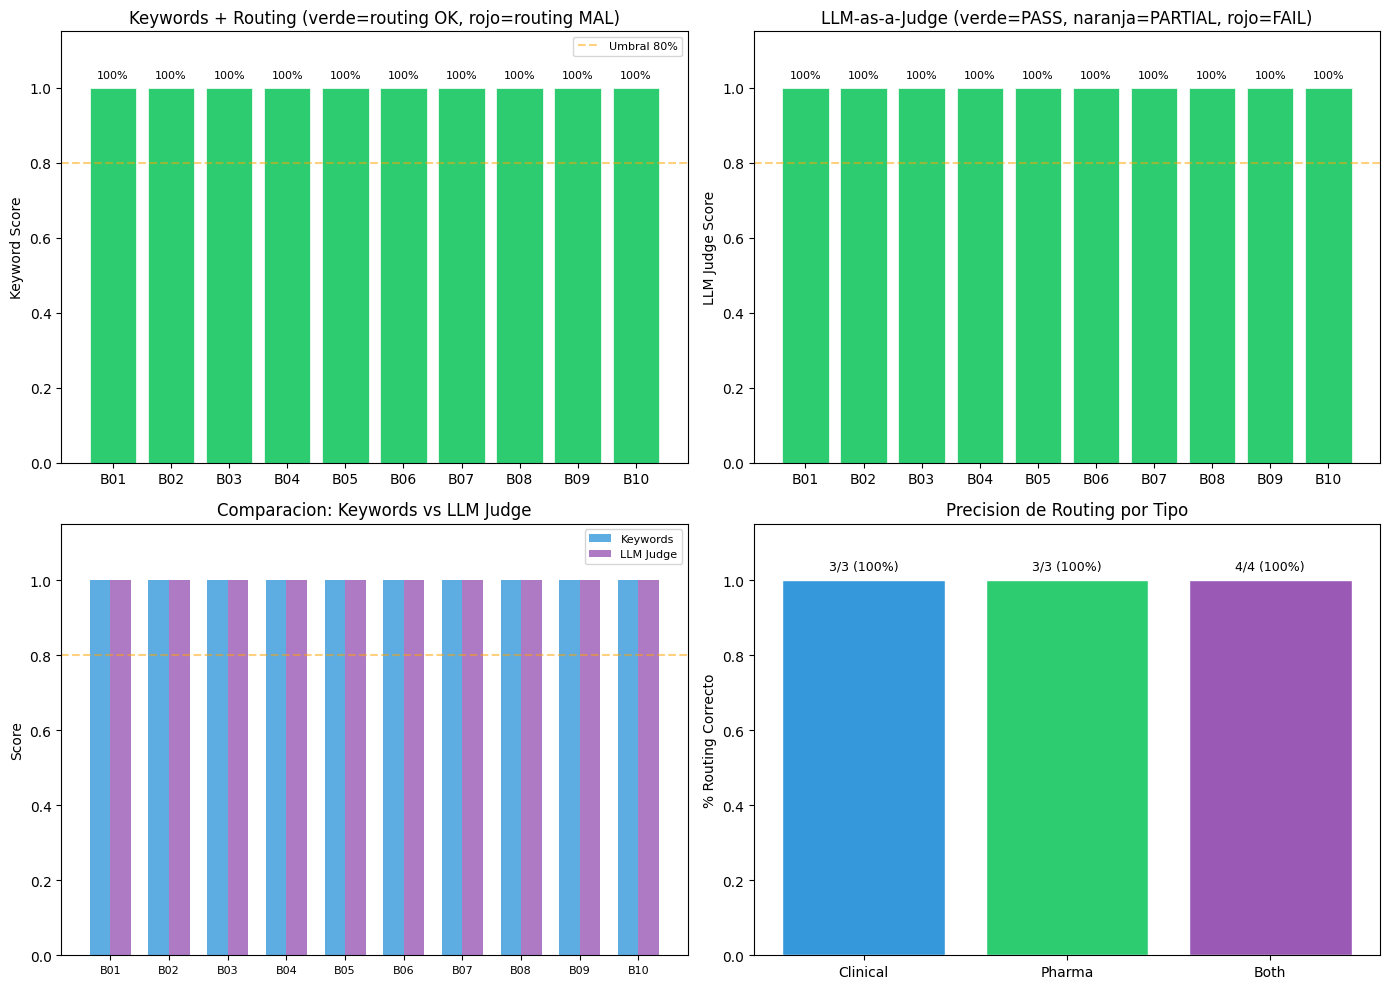

Grafico guardado: benchmark_multiagent.png


In [29]:
# ============================================================
# NO MODIFICAR - Visualizacion
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Keywords + Routing
ax1 = axes[0, 0]
ids = [r["id"] for r in keyword_results]
scores = [r["kw_score"] for r in keyword_results]
colors = ["#2ecc71" if r["routing_correct"] else "#e74c3c" for r in keyword_results]
bars = ax1.bar(ids, scores, color=colors, edgecolor="white", linewidth=0.5)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel("Keyword Score")
ax1.set_title("Keywords + Routing (verde=routing OK, rojo=routing MAL)")
ax1.axhline(y=0.8, color="orange", linestyle="--", alpha=0.5, label="Umbral 80%")
for bar, score in zip(bars, scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{score:.0%}", ha="center", va="bottom", fontsize=8)
ax1.legend(fontsize=8)

# Panel 2: LLM Judge
ax2 = axes[0, 1]
j_scores = [r["score"] for r in judge_results]
j_colors = ["#2ecc71" if r["status"] == "PASS" else "#f39c12" if r["status"] == "PARTIAL" else "#e74c3c" for r in judge_results]
bars2 = ax2.bar(ids, j_scores, color=j_colors, edgecolor="white", linewidth=0.5)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel("LLM Judge Score")
ax2.set_title("LLM-as-a-Judge (verde=PASS, naranja=PARTIAL, rojo=FAIL)")
ax2.axhline(y=0.8, color="orange", linestyle="--", alpha=0.5)
for bar, score in zip(bars2, j_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{score:.0%}", ha="center", va="bottom", fontsize=8)

# Panel 3: Comparacion global
ax3 = axes[1, 0]
x = np.arange(len(ids))
width = 0.35
ax3.bar(x - width/2, scores, width, label="Keywords", color="#3498db", alpha=0.8)
ax3.bar(x + width/2, j_scores, width, label="LLM Judge", color="#9b59b6", alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(ids, fontsize=8)
ax3.set_ylim(0, 1.15)
ax3.set_ylabel("Score")
ax3.set_title("Comparacion: Keywords vs LLM Judge")
ax3.legend(fontsize=8)
ax3.axhline(y=0.8, color="orange", linestyle="--", alpha=0.5)

# Panel 4: Routing por tipo
ax4 = axes[1, 1]
routing_types = ["clinical", "pharma", "both"]
routing_correct_by_type = {}
routing_total_by_type = {}
for r in keyword_results:
    rt = r["expected_routing"]
    routing_total_by_type[rt] = routing_total_by_type.get(rt, 0) + 1
    if r["routing_correct"]:
        routing_correct_by_type[rt] = routing_correct_by_type.get(rt, 0) + 1
rt_labels = []
rt_correct = []
rt_total = []
for rt in routing_types:
    if rt in routing_total_by_type:
        rt_labels.append(rt.capitalize())
        rt_correct.append(routing_correct_by_type.get(rt, 0))
        rt_total.append(routing_total_by_type[rt])
rt_pcts = [c/t if t > 0 else 0 for c, t in zip(rt_correct, rt_total)]
bars4 = ax4.bar(rt_labels, rt_pcts, color=["#3498db", "#2ecc71", "#9b59b6"], edgecolor="white")
ax4.set_ylim(0, 1.15)
ax4.set_ylabel("% Routing Correcto")
ax4.set_title("Precision de Routing por Tipo")
for bar, pct, c, t in zip(bars4, rt_pcts, rt_correct, rt_total):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{c}/{t} ({pct:.0%})", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("benchmark_multiagent.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado: benchmark_multiagent.png")

---

## Ejercicio 5: Analizar resultados

Mira los graficos del benchmark y responde:
- Que preguntas tuvieron routing incorrecto? Por que?
- Hay diferencia entre el score de keywords y el de LLM Judge? Que explica la diferencia?
- Que tipo de preguntas (clinical, pharma, both) tiene mejor routing?

---

## Ejercicio 6: Preguntas conceptuales

### 6.1 -- Routing del supervisor

**Pregunta:** Como decide el supervisor a que agente derivar cada pregunta? Que papel juega el docstring de cada tool de routing?

El supervisor decide a qué agente derivar cada pregunta analizando el contexto de la consulta (lo que pide el usuario) y comparándolo con el Docstring de cada tool de routing.
El Docstring tiene el papel de ser la instrucción que le dirá al modelo que tipo de información maneja, necesita y devuelve y bajo que condiciones debe ser utilizada

### 6.2 -- Ventajas y desventajas

**Pregunta:** Cuales son las ventajas y desventajas de usar un patron supervisor vs. un solo agente con todas las tools?

El supervisor puede delegar de mejor manera las tareas para cada grupo de tool que serias los sub-agentes, de esta manera se reduce el riesgo de que el agente utilice erróneamente herramientas y que no posean la información que necesita el agente. Ademas permite dividir la cantidad necesaria de tokens que requiere el agente y no tener un super-agente que pierda memoria debido a que requiere demasiados tokens iniciales.

### 6.3 -- Preguntas cruzadas

**Pregunta:** Por que las preguntas que cruzan ambos dominios son las mas dificiles para el sistema?

Son las las difíciles porque el agente debe primero debe dividir la pregunta en dos y saber que parte va para que agente, resultado el cual debe interpretar y saber si las respuestas son las esperadas, todo esto ademas de no romper el hilo de la gestión. Si falla un solo prompt en el camino o si atribuye mal lo que debe saber un agente cae toda la respuesta.

### 6.4 -- Como mejorarias el sistema?

**Pregunta:** Propone al menos 3 mejoras concretas al sistema multiagente.

1- Añadir un mecanismo de memoria, permitiendo que los distintos agentes entiendan y mantengan el hilo de una charla a través de varias consultas sin resetearse y arrancar de cero cada vez.
2- Implementar un agente mas que sea el revisor al final de LangGraph que se asegure de que la respuesta final generada por los sub-agentes realmente contestó por completo lo que el usuario preguntó.
Que el enrutamiento (ask_both_agents) funcione de un modo "desglosado", es decir, que el propio supervisor no envíe la misma pregunta ciega y gigante a los dos agentes, sino que tenga una tool que descomponga la pregunta cruzada en dos sub-preguntas más pequeñas exclusivas para cada dominio particular.